[INFO] 76 cellules classifiées.

=== DISTRIBUTION DES CLASSES PRÉDITES ===
predicted_class
MONOCYTE      73
NEUTROPHIL     2
LYMPHOCYTE     1
Name: count, dtype: int64


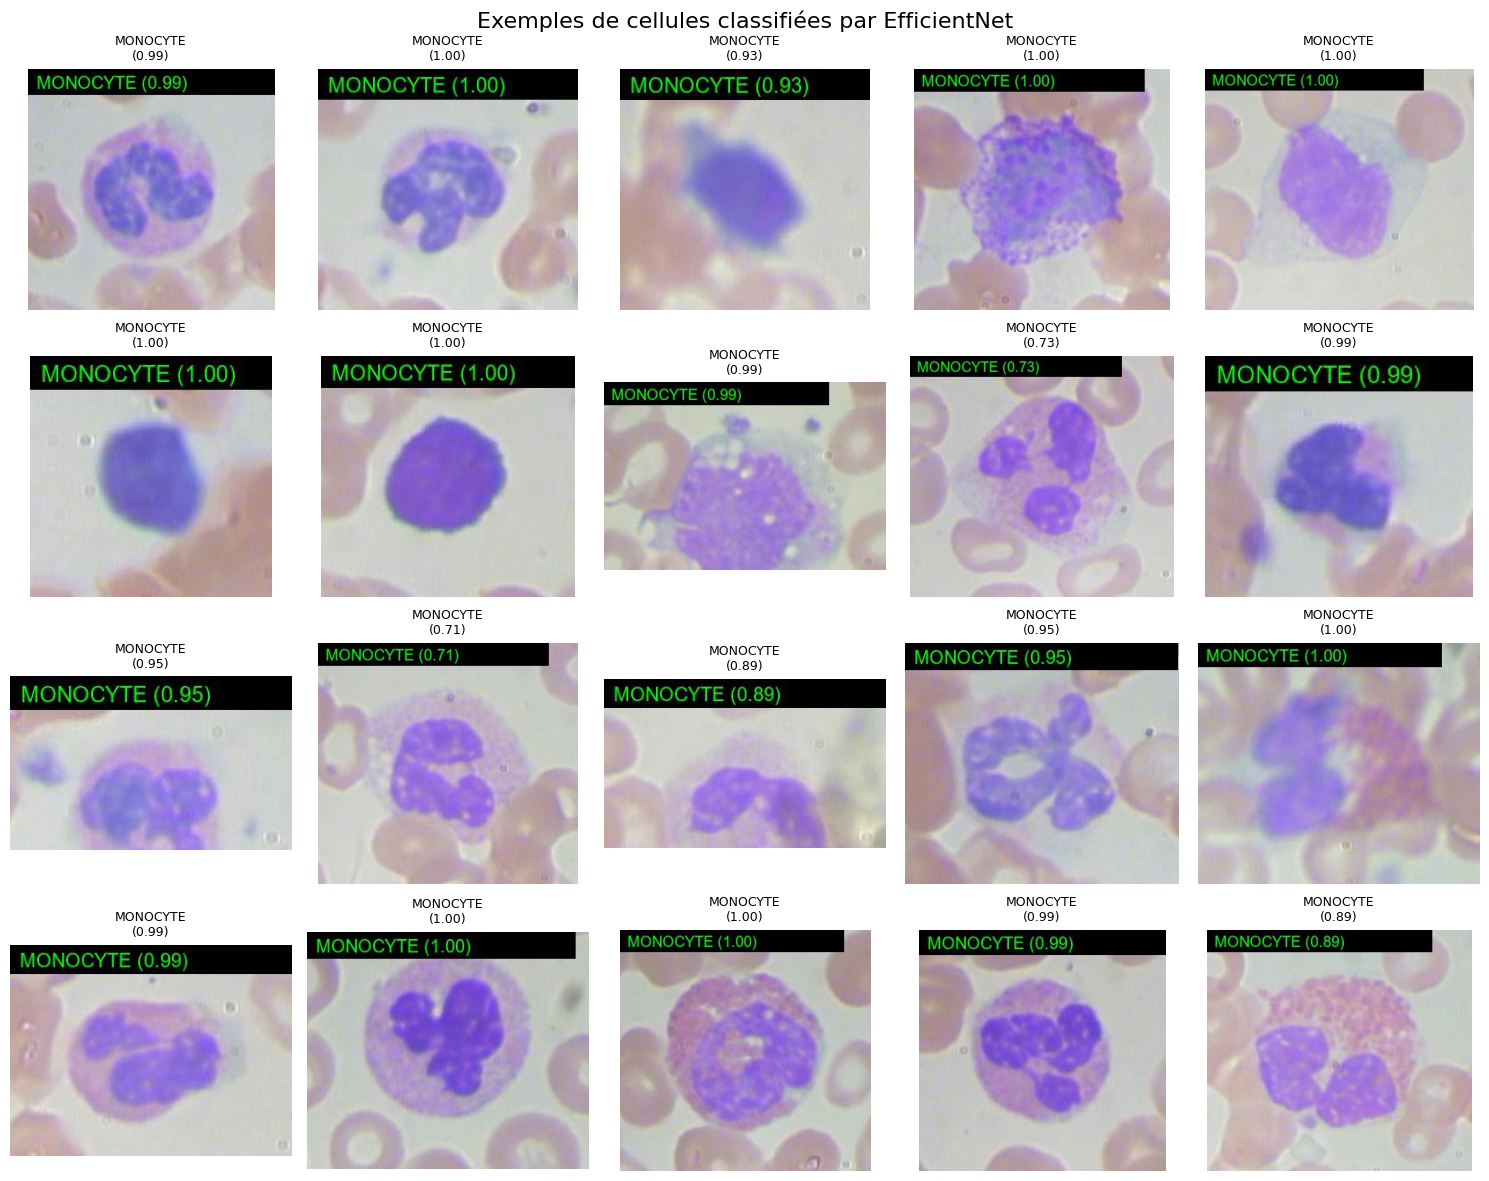


=== STATISTIQUES DE CONFIANCE ===
Confiance moyenne : 0.942
Confiance min : 0.524
Confiance max : 1.000


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path
import random

PROJECT_ROOT = Path("..")
CSV_PATH = PROJECT_ROOT / "outputs" / "reports" / "extracted_cells_predictions.csv"
CLASSIFIED_DIR = PROJECT_ROOT / "data" / "processed" / "classified_cells"

if not CSV_PATH.exists():
    print("[WARNING] Fichier CSV introuvable. Exécutez d'abord scripts/10_classify_extracted_cells.py")
else:
    df = pd.read_csv(CSV_PATH)
    print(f"[INFO] {len(df)} cellules classifiées.")
    
   
    print("\n=== DISTRIBUTION DES CLASSES PRÉDITES ===")
    print(df['predicted_class'].value_counts())
    
  
    sample_df = df.sample(n=min(20, len(df)))
    
    fig, axes = plt.subplots(4, 5, figsize=(15, 12))
    
    for i, (idx, row) in enumerate(sample_df.iterrows()):
        if i >= 20:
            break
        ax = axes[i // 5, i % 5]
        
        img_path = Path(row['output_path'])
        if img_path.exists():
            img = Image.open(img_path)
            ax.imshow(img)
            ax.set_title(f"{row['predicted_class']}\n({row['confidence']:.2f})", fontsize=9)
        else:
            ax.set_title("Image manquante")
        ax.axis('off')
    
    plt.suptitle("Exemples de cellules classifiées par EfficientNet", fontsize=16)
    plt.tight_layout()
    plt.show()
    
    
    print("\n=== STATISTIQUES DE CONFIANCE ===")
    print(f"Confiance moyenne : {df['confidence'].mean():.3f}")
    print(f"Confiance min : {df['confidence'].min():.3f}")
    print(f"Confiance max : {df['confidence'].max():.3f}")